# Combined Diamond + Eikosany Optimisation

Finds the `shiftVector` that maximises the number of Penrose tiling nodes
that are members of the **Hexadic Diamond** or the **Eikosany**.

Unlike the proxy optimisations in `penrose5D.ipynb` (which test only the
31 / 20 canonical lattice vectors), this notebook regenerates `selPoints`
from the full 7⁵ integer grid for every trial `sv` — exactly as the main
pipeline does — and applies the same ratio-based Diamond membership test,
including paths with coordinates outside {−1, 0, 1}.

The Diamond ratio check uses log-arithmetic instead of SymPy for speed:
it computes `(pt5 · log rᵢ) mod log 2` and compares against precomputed
fingerprints of the 31 Diamond intervals.

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
from scipy.spatial import ConvexHull, Delaunay
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt
from sympy import symbols, Integer, Rational

from ji_tiling import basis2D, in_hull

## Projection setup

Identical to `penrose5D.ipynb`: cyclic permutation matrix → eigenvectors →
2D projection `p` (E∥) and 3D projection `y` (E⊥ + [1,1,1,1,1]).

In [2]:
rotationMatrix = np.array([
    [0.,0.,0.,0.,1.],
    [1.,0.,0.,0.,0.],
    [0.,1.,0.,0.,0.],
    [0.,0.,1.,0.,0.],
    [0.,0.,0.,1.,0.]
])

eigenValues, eigenVectors = np.linalg.eig(rotationMatrix)

# Sort eigenvalues by angle so indices are consistent regardless of numpy's eig ordering.
# E∥ pair: eigenvalues closest to e^(±2πi/5) (angle ≈ ±72°)
# E⊥ pair: eigenvalues closest to e^(±4πi/5) (angle ≈ ±144°)
angles = np.angle(eigenValues)          # in (−π, π]
sort_idx = np.argsort(angles)           # ascending angle: −4π/5, −2π/5, 0, +2π/5, +4π/5
eigenVectors = eigenVectors[:, sort_idx]
# After sort: col 0 ≈ e^(−4πi/5), col 1 ≈ e^(−2πi/5), col 2 = 1,
#             col 3 ≈ e^(+2πi/5), col 4 ≈ e^(+4πi/5)

# p = basis2D(eigenVectors, 3, 1)   # (2,5) — E∥: cols 3 & 1 form conjugate pair
p = basis2D(eigenVectors, 1, 3)
y = np.vstack((
    basis2D(eigenVectors, 4, 0),
    np.array([1,1,1,1,1]) / np.linalg.norm(np.array([1,1,1,1,1]))
))                                 # (3,5) — E⊥: cols 4 & 0 form conjugate pair

-->5D basis vectors are rotated in 2D plane by (2.0π)/5
-->5D basis vectors are rotated in 2D plane by (3.9999999999999996π)/5


In [3]:
p

array([[ 0.63245553,  0.19543951, -0.51166727, -0.51166727,  0.19543951],
       [ 0.        , -0.60150096, -0.37174803,  0.37174803,  0.60150096]])

In [4]:
y

array([[-0.19543951, -0.19543951,  0.51166727, -0.63245553,  0.51166727],
       [ 0.60150096, -0.60150096,  0.37174803,  0.        , -0.37174803],
       [ 0.4472136 ,  0.4472136 ,  0.4472136 ,  0.4472136 ,  0.4472136 ]])

## Convex hull (acceptance window)

In [5]:
s = 0.999
cell = np.zeros((32, 5))
i = 0
for i5 in range(2):
    for i4 in range(2):
        for i3 in range(2):
            for i2 in range(2):
                for i1 in range(2):
                    cell[i, :] = s * np.array([i1, i2, i3, i4, i5])
                    i += 1

convexHullSeed = (y @ cell.T).T
hull           = ConvexHull(convexHullSeed)
hull_del       = Delaunay(convexHullSeed[hull.vertices])

print(f'Hull vertices: {len(hull.vertices)}')

Hull vertices: 22


## Diamond ratios and starting shift vector

In [6]:
diamond_ratios = set([
    Rational(3,2),  Rational(16,9),  Rational(5,4),  Rational(16,11),
    Rational(7,4),  Rational(4,3),   Rational(9,8),  Rational(8,5),
    Rational(11,8), Rational(8,7),
    Rational(10,7), Rational(12,11), Rational(14,9), Rational(5,3),
    Rational(18,11),Rational(7,5),   Rational(11,6), Rational(9,7),
    Rational(6,5),  Rational(11,9),
    Rational(12,9), Rational(10,9),  Rational(20,11),Rational(14,11),
    Rational(7,6),  Rational(9,6),   Rational(9,5),  Rational(11,10),
    Rational(11,7), Rational(12,7),
    Rational(1)
])

# Starting guess from Eikosany optimisation in penrose5D
shiftVector = np.array([-0.36844, -0.491094, 0.315972, 0.430247, 0.113314])
print(f'Starting shiftVector: {np.round(shiftVector, 6)}')

Starting shiftVector: [-0.36844  -0.491094  0.315972  0.430247  0.113314]


## Combined optimisation

In [7]:
from itertools import combinations

rI_float = np.array([3., 5., 7., 9., 11.])
log2     = np.log(2.0)
log_rI   = np.log(rI_float)

def _norm(x):
    """Normalise a positive ratio into [1, 2)."""
    while x >= 2.0: x /= 2.0
    while x < 1.0:  x *= 2.0
    return x

# --- Precompute Diamond real values in [1, 2) ---
diamond_float = np.array(sorted(set(_norm(float(r)) for r in diamond_ratios)))

# --- Precompute Eikosany real values in [1, 2) ---
# Generators {1,3,5,7,9,11}; choose 3.  "1" contributes no factor,
# so products with "1" are 2-element products of {3,5,7,9,11}.
# Encoded as {0,1}^5 vectors with sum 2 or 3 (indices into rI_float).
eiko_float = sorted(set(
    _norm(np.prod(rI_float[list(idx)]))
    for r in (2, 3)
    for idx in combinations(range(5), r)
))
eiko_float = np.array(eiko_float)

# --- Combined log-normalised target fingerprints ---
target_log_norm = np.unique(
    np.concatenate([np.log(diamond_float), np.log(eiko_float)]) % log2
)
target_log_norm = np.log(diamond_float) % log2

print(f'Diamond target values  : {len(diamond_float)}')
print(f'Eikosany target values : {len(eiko_float)}')
print(f'Combined unique targets: {len(target_log_norm)}')

# --- Precompute integer grid (d=3) — explicit loops matching penrose5D exactly ---
d = 3
_pts = []
for i5 in range(-d, d+1):
    for i4 in range(-d, d+1):
        for i3 in range(-d, d+1):
            for i2 in range(-d, d+1):
                for i1 in range(-d, d+1):
                    _pts.append([i1, i2, i3, i4, i5])
int_grid = np.array(_pts)   # (7^5, 5)  column k = i(k+1), matching penrose5D z5
print(f'Integer grid: {len(int_grid)} points')


def count_combined(sv_free):
    """Count hull points whose normalised ratio matches a Diamond or Eikosany value."""
    sv        = np.append(sv_free, -sv_free.sum())
    shifted   = int_grid + sv
    projected = (y @ shifted.T).T
    sel_int   = int_grid[in_hull(projected, hull_del)]

    if len(sel_int) == 0:
        return 0

    # Log-ratio for every selected point, normalised to [0, log2)
    log_norm = (sel_int @ log_rI) % log2                     # (N,)

    # Vectorised nearest-target check
    diffs   = np.abs(log_norm[:, None] - target_log_norm[None, :])  # (N, T)
    return int((diffs.min(axis=1) < 1e-7).sum())


# --- Baseline ---
baseline = count_combined(shiftVector[:4])
print(f'\nBaseline combined count: {baseline}')

# --- Global optimisation ---
result = differential_evolution(
    lambda sv: -count_combined(sv),
    bounds   = [(-0.5, 0.5)] * 4,
    seed     = 42,
    maxiter  = 300,
    popsize  = 15,
    tol      = 0,
    polish   = True,
    disp     = False,
    x0       = shiftVector[:4],
)

sv_opt = np.append(result.x, -result.x.sum())
best   = -int(result.fun)

print(f'\nOptimal shiftVector : {np.round(sv_opt, 6)}')
print(f'Combined nodes found: {best}  (baseline: {baseline})')
print(f'Improvement         : {best - baseline}')
print(f'\nTo use in penrose5D, replace shiftVector with:')
print(f'  shiftVector = np.array({list(np.round(sv_opt, 6))})')

Diamond target values  : 29
Eikosany target values : 20
Combined unique targets: 29
Integer grid: 16807 points

Baseline combined count: 5

Optimal shiftVector : [-0.378099  0.421474 -0.4469    0.142218  0.261307]
Combined nodes found: 9  (baseline: 5)
Improvement         : 4

To use in penrose5D, replace shiftVector with:
  shiftVector = np.array([np.float64(-0.378099), np.float64(0.421474), np.float64(-0.4469), np.float64(0.142218), np.float64(0.261307)])


## Verify optimal shift: list Diamond and Eikosany nodes

Diamond nodes : 9
  1  x1
  1.11111  x1
  1.125  x1
  1.25  x1
  1.375  x1
  1.5  x1
  1.57143  x1
  1.66667  x1
  1.75  x1
Eikosany nodes: 17
  1.03125  x2
  1.09375  x1
  1.16016  x1
  1.23047  x1
  1.28906  x1
  1.3125  x1
  1.35352  x1
  1.40625  x1
  1.47656  x1
  1.54688  x1
  1.64062  x1
  1.71875  x1
  1.80469  x1
  1.875  x1
  1.96875  x2


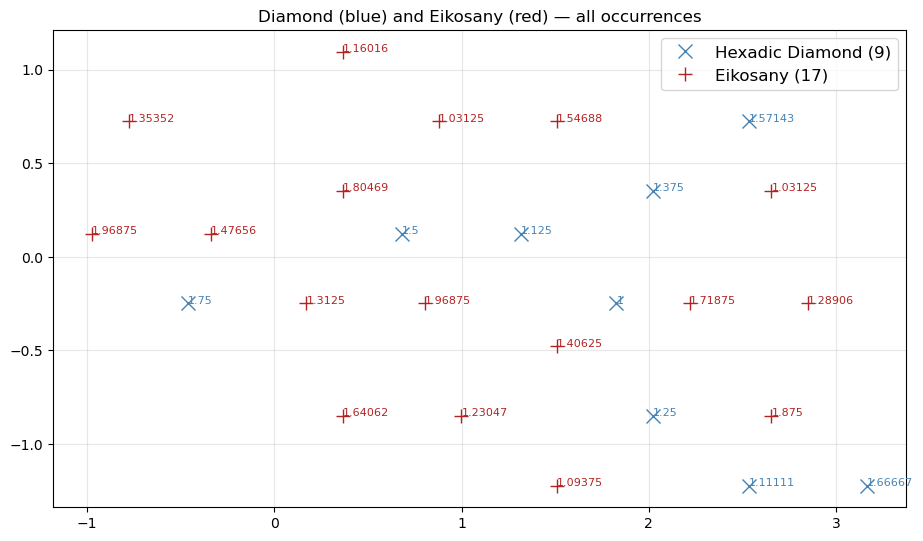

In [8]:
# Use starting shiftVector for direct comparison with penrose5D.
# Replace with sv_opt to inspect the optimised result.
sv        = sv_opt # shiftVector
shifted   = int_grid + sv
projected = (y @ shifted.T).T
sel_int   = int_grid[in_hull(projected, hull_del)]

log_norm_sel = (sel_int @ log_rI) % log2   # (N,)

# Separate Diamond and Eikosany log-norm fingerprints
diamond_log_norm = np.log(diamond_float) % log2
eiko_log_norm    = np.log(eiko_float)    % log2

tol = 1e-7

# For each hull point find the nearest Diamond / Eikosany target
d_idx = np.argmin(np.abs(log_norm_sel[:, None] - diamond_log_norm[None, :]), axis=1)
e_idx = np.argmin(np.abs(log_norm_sel[:, None] - eiko_log_norm[None,    :]), axis=1)

is_diamond = np.abs(log_norm_sel - diamond_log_norm[d_idx]) < tol
is_eiko    = np.abs(log_norm_sel - eiko_log_norm[e_idx])    < tol

# Matched ratio value for every occurrence (duplicates included)
diamond_vals_found = diamond_float[d_idx[is_diamond]]
eiko_vals_found    = eiko_float[e_idx[is_eiko]]

xy_all     = (sel_int + sv) @ p.T          # (N, 2)
xy_diamond = xy_all[is_diamond]
xy_eiko    = xy_all[is_eiko]
labels_d   = [f'{v:.6g}' for v in diamond_vals_found]
labels_e   = [f'{v:.6g}' for v in eiko_vals_found]

print(f'Diamond nodes : {is_diamond.sum()}')
for v, cnt in zip(*np.unique(labels_d, return_counts=True)):
    print(f'  {v}  x{cnt}')
print(f'Eikosany nodes: {is_eiko.sum()}')
for v, cnt in zip(*np.unique(labels_e, return_counts=True)):
    print(f'  {v}  x{cnt}')

fig, ax = plt.subplots(figsize=(11, 11))
if len(xy_diamond):
    ax.plot(xy_diamond[:,0], xy_diamond[:,1], 'x', color='steelblue',
            markersize=10, label=f'Hexadic Diamond ({is_diamond.sum()})', zorder=3)
    for i, rl in enumerate(labels_d):
        ax.annotate(rl, xy=xy_diamond[i], fontsize=8, color='steelblue')
if len(xy_eiko):
    ax.plot(xy_eiko[:,0], xy_eiko[:,1], '+', color='firebrick',
            markersize=10, label=f'Eikosany ({is_eiko.sum()})', zorder=3)
    for i, rl in enumerate(labels_e):
        ax.annotate(rl, xy=xy_eiko[i], fontsize=8, color='firebrick')
ax.legend(fontsize=12)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.title('Diamond (blue) and Eikosany (red) — all occurrences')
plt.show()